# **Implementation and Comparison of Loss Functions**

# Objective:

To understand how neural networks measure prediction errors by implementing Mean Squared Error (MSE) and Cross-Entropy Loss using Python and NumPy, and by comparing the difference between actual and predicted values.

# Background: What is a loss function?

A **loss function** turns the question *"how wrong is the model?"* into a single number. During training, a neural network:

1. makes a prediction (forward pass),
2. measures the error with a loss function,
3. uses that error to adjust its weights (backpropagation and gradient descent),
4. repeats until the loss is small.

The two loss functions used in this assignment are:

- **Mean Squared Error:** MSE = (1/n) Σ (y − ŷ)²
- **Binary Cross-Entropy:** BCE = −(1/n) Σ [ y·log(ŷ) + (1 − y)·log(1 − ŷ) ]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Actual class labels and predicted outputs

A simple binary classification problem (for example, *is this email spam?*). Label **1** means the positive class and **0** means the negative class. The model outputs the probability of class 1.

In [2]:
y_actual = np.array([1, 0, 1, 0])

y_predicted = np.array([0.9, 0.2, 0.7, 0.4])

print("Actual labels:", y_actual)
print("Predicted outputs:", y_predicted)

Actual labels: [1 0 1 0]
Predicted outputs: [0.9 0.2 0.7 0.4]


In [3]:
# Side-by-side view of the data
print(f"{'Sample':<8}{'Actual':>8}{'Predicted':>12}{'Difference':>13}")
print("-" * 41)
for i, (a, p) in enumerate(zip(y_actual, y_predicted), start=1):
    print(f"{i:<8}{a:>8}{p:>12.2f}{a - p:>13.2f}")

Sample    Actual   Predicted   Difference
-----------------------------------------
1              1        0.90         0.10
2              0        0.20        -0.20
3              1        0.70         0.30
4              0        0.40        -0.40


# Task 2: Calculate Mean Squared Error and Cross-Entropy Loss

## 2.1 Mean Squared Error, step by step

In [4]:
errors = y_actual - y_predicted        # step 1: error for each sample
squared_errors = errors ** 2           # step 2: square each error
mse = np.mean(squared_errors)          # step 3: average

print("Errors         :", errors)
print("Squared errors :", squared_errors)
print("Mean Squared Error:", mse)

Errors         : [ 0.1 -0.2  0.3 -0.4]
Squared errors : [0.01 0.04 0.09 0.16]
Mean Squared Error: 0.07500000000000001


## 2.2 Binary Cross-Entropy, step by step

Predictions are clipped to a tiny range so that `log(0)` never occurs.

In [5]:
epsilon = 1e-15
y_pred_clipped = np.clip(
    y_predicted, epsilon, 1 - epsilon
)

# loss for each sample
per_sample_bce = -(
    y_actual * np.log(y_pred_clipped)
    + (1 - y_actual) * np.log(1 - y_pred_clipped)
)

bce = np.mean(per_sample_bce)

print("Per-sample cross-entropy:", per_sample_bce)
print("Binary Cross-Entropy Loss:", bce)

Per-sample cross-entropy: [0.10536052 0.22314355 0.35667494 0.51082562]
Binary Cross-Entropy Loss: 0.2990011586691898


## 2.3 Reusable functions

The same calculations wrapped into functions so they can be used on any data.

In [6]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


# Check that the functions give the same answers as the step-by-step code
print("MSE (function):", mean_squared_error(y_actual, y_predicted))
print("BCE (function):", binary_cross_entropy(y_actual, y_predicted))

MSE (function): 0.07500000000000001
BCE (function): 0.2990011586691898


In [7]:
# Per-sample comparison of the two losses
print(f"{'Actual':>7}{'Predicted':>11}{'Squared Error':>16}{'Cross-Entropy':>16}")
print("-" * 50)
for a, p, se, ce in zip(y_actual, y_predicted, squared_errors, per_sample_bce):
    print(f"{a:>7}{p:>11.2f}{se:>16.4f}{ce:>16.4f}")

 Actual  Predicted   Squared Error   Cross-Entropy
--------------------------------------------------
      1       0.90          0.0100          0.1054
      0       0.20          0.0400          0.2231
      1       0.70          0.0900          0.3567
      0       0.40          0.1600          0.5108


# Task 3: Compare the results

In [8]:
print("Loss Function Comparison")
print("------------------------")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Binary Cross-Entropy:     {bce:.4f}")

if mse < bce:
    print("MSE has the smaller numerical value.")
elif bce < mse:
    print("Binary Cross-Entropy has the smaller numerical value.")
else:
    print("Both loss values are equal.")

Loss Function Comparison
------------------------
Mean Squared Error (MSE): 0.0750
Binary Cross-Entropy:     0.2990
MSE has the smaller numerical value.


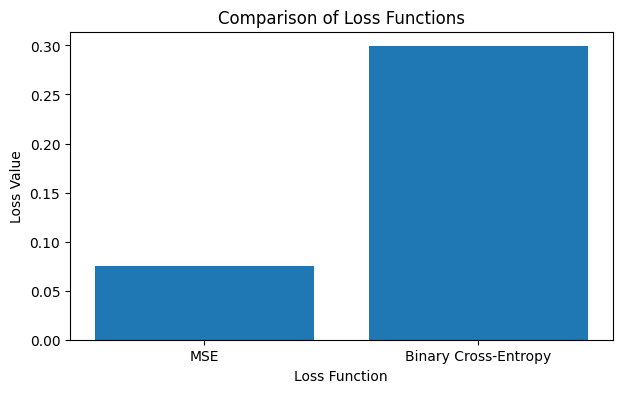

In [9]:
loss_names = ["MSE", "Binary Cross-Entropy"]
loss_values = [mse, bce]

plt.figure(figsize=(7, 4))
plt.bar(loss_names, loss_values)
plt.title("Comparison of Loss Functions")
plt.xlabel("Loss Function")
plt.ylabel("Loss Value")
plt.show()

## 3.1 Comparing a good, a bad and a confidently wrong model

To see how each loss behaves, the same actual labels are used with three different sets of predictions.

In [10]:
models = {
    "Good model":      np.array([0.90, 0.10, 0.90, 0.10]),
    "Current model":   y_predicted,
    "Bad model":       np.array([0.40, 0.60, 0.30, 0.70]),
    "Confident wrong": np.array([0.01, 0.99, 0.01, 0.99]),
}

mse_list, bce_list = [], []
print(f"{'Model':<18}{'MSE':>10}{'Cross-Entropy':>16}")
print("-" * 44)
for name, pred in models.items():
    m = mean_squared_error(y_actual, pred)
    b = binary_cross_entropy(y_actual, pred)
    mse_list.append(m)
    bce_list.append(b)
    print(f"{name:<18}{m:>10.4f}{b:>16.4f}")

Model                    MSE   Cross-Entropy
--------------------------------------------
Good model            0.0100          0.1054
Current model         0.0750          0.2990
Bad model             0.4250          1.0601
Confident wrong       0.9801          4.6052


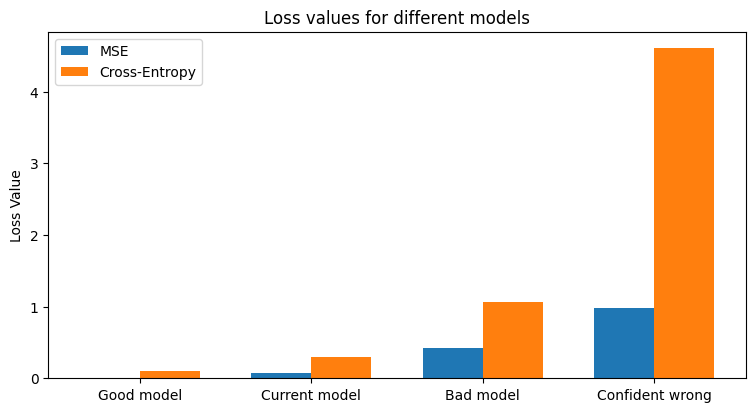

In [11]:
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, mse_list, width, label="MSE")
plt.bar(x + width/2, bce_list, width, label="Cross-Entropy")
plt.xticks(x, list(models.keys()))
plt.ylabel("Loss Value")
plt.title("Loss values for different models")
plt.legend()
plt.show()

## 3.2 How each loss penalizes mistakes

For an email that is truly spam (y = 1), the plot shows the loss as the predicted probability changes from 0 to 1. MSE stays small and flat, whereas cross-entropy rises sharply as the prediction moves toward the wrong answer.

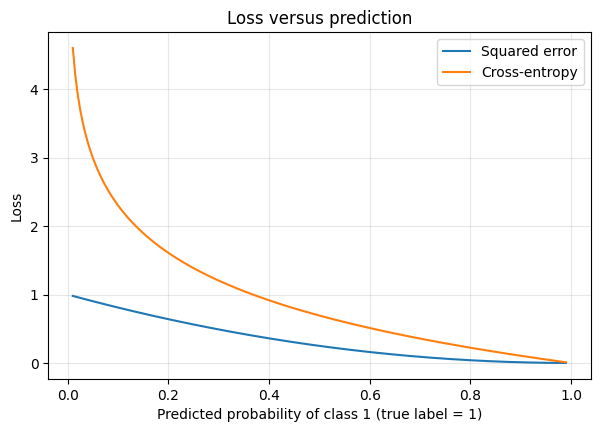

In [12]:
p = np.linspace(0.01, 0.99, 200)
y_true_one = 1

mse_curve = (y_true_one - p) ** 2
bce_curve = -np.log(p)

plt.figure(figsize=(7, 4.5))
plt.plot(p, mse_curve, label="Squared error")
plt.plot(p, bce_curve, label="Cross-entropy")
plt.xlabel("Predicted probability of class 1 (true label = 1)")
plt.ylabel("Loss")
plt.title("Loss versus prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.3 Learning speed: gradients

For a sigmoid output with true label y = 1, the gradient of the loss with respect to the logit is:

- MSE: 2(p − 1) · p · (1 − p)
- Cross-Entropy: (p − 1)

A larger gradient means a bigger correction to the weights.

In [13]:
print(f"{'p':>6}{'MSE gradient':>15}{'CE gradient':>14}")
print("-" * 35)
for pv in [0.9, 0.5, 0.1, 0.01]:
    g_mse = 2 * (pv - 1) * pv * (1 - pv)
    g_ce = pv - 1
    print(f"{pv:>6}{g_mse:>15.4f}{g_ce:>14.4f}")

     p   MSE gradient   CE gradient
-----------------------------------
   0.9        -0.0180       -0.1000
   0.5        -0.2500       -0.5000
   0.1        -0.1620       -0.9000
  0.01        -0.0196       -0.9900


When the model is very wrong (p = 0.01), the MSE gradient is nearly zero, so learning is slow. The cross-entropy gradient stays large, so the model corrects itself quickly.

## 3.4 Extension: multi-class classification

With more than two classes (for example cat, dog and bird), labels are one-hot encoded and **categorical cross-entropy** is used.

In [14]:
def categorical_cross_entropy(Y, P, eps=1e-15):
    P = np.clip(P, eps, 1.0)
    return -np.mean(np.sum(Y * np.log(P), axis=1))

# classes: cat, dog, bird
Y = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]])

P = np.array([[0.7, 0.2, 0.1],
              [0.1, 0.8, 0.1],
              [0.2, 0.3, 0.5]])

print("MSE                    :", round(mean_squared_error(Y, P), 4))
print("Categorical Cross-Entropy:", round(categorical_cross_entropy(Y, P), 4))

MSE                    : 0.0644
Categorical Cross-Entropy: 0.4243


# Results and Comparison

The calculated loss values for the main example are:

| Loss function | Calculated value |
|---|---|
| Mean Squared Error (MSE) | 0.0750 |
| Binary Cross-Entropy (BCE) | 0.2990 |

MSE (0.0750) is numerically smaller than BCE (0.2990) for this example.

**Observations from the experiments**

1. Both loss functions give a low value for the good model and a high value for the bad model, so both measure prediction error correctly.
2. For the confidently wrong model, MSE stays below 1, while cross-entropy becomes very large. Cross-entropy punishes confident incorrect predictions much more heavily.
3. The loss-versus-prediction plot shows that cross-entropy grows without limit as the prediction moves toward the wrong class, whereas squared error is bounded.
4. The gradient table shows that MSE gives almost no learning signal when a sigmoid output is very wrong, but cross-entropy keeps a strong signal.

# Explanation

**MSE:** Measures the average squared difference between actual and predicted values. It is primarily used for regression problems, but can also be applied to classification.

**Cross-Entropy:** Measures the difference between actual class labels and predicted probabilities. It is commonly used in classification problems, especially with sigmoid or softmax output layers.

**Comparison:** Both functions measure prediction errors, but their numerical values are not directly comparable because they use different mathematical formulas and scales. Cross-Entropy is generally preferred for classification because it provides a suitable probabilistic loss, penalizes confident incorrect predictions heavily, and gives stronger gradients for learning.

# When to use each loss function

| | Mean Squared Error | Cross-Entropy |
|---|---|---|
| **Problem type** | Regression (continuous values) | Classification (categories) |
| **Examples** | House price, temperature, sales forecast | Spam detection, image classification, sentiment analysis |
| **Output layer** | Linear | Sigmoid (binary) or Softmax (multi-class) |
| **What it measures** | Squared distance between values | Difference between probability distributions |
| **Penalty for confident mistakes** | Moderate (bounded for probabilities) | Very high (unbounded) |
| **Learning speed with sigmoid/softmax** | Can be slow | Fast and stable |

**Rule of thumb:** use MSE when predicting a number, and cross-entropy when predicting a class or probability.

# Conclusion

Loss functions measure how far a model's predictions are from the actual values and guide the learning process. Implementing MSE and cross-entropy on the same data showed that both capture prediction error, but cross-entropy is more suitable for classification because it penalizes confident wrong predictions strongly and provides better gradients. MSE remains the natural choice for regression tasks. Choosing a loss function that matches the type of problem is an important step when designing a neural network.